#### Importing Packages

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.signal import periodogram
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess



#### Importing Data

In [8]:
Transactional_data = pd.read_csv('transactions_data.csv')
Cards_data = pd.read_csv('cards_data.csv')
User_data = pd.read_csv('users_data.csv')


#### In this first phase, I demonstrate my expertise in SQL and data management by efficiently querying, transforming, and analyzing datasets to extract actionable insights. Please note that all these results can be achieved with R, SQL, or SAS, however Python was selected due to its free availability and user-friendly nature.

#### Structural Analysis on Transactional data

#### Displaying the table

In [9]:
Transactional_data.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


#### Checking the dimension of the table

In [4]:
Transactional_data.shape 

(13305915, 12)

#### Checking the columns

In [5]:
Transactional_data.columns 

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='str')

#### Checking each column data type

In [6]:
Transactional_data.dtypes ### 

id                  int64
date                  str
client_id           int64
card_id             int64
amount                str
use_chip              str
merchant_id         int64
merchant_city         str
merchant_state        str
zip               float64
mcc                 int64
errors                str
dtype: object

#### Checking unique values per column

In [7]:
Transactional_data.nunique()  

id                13305915
date               4136496
client_id             1219
card_id               4071
amount               81161
use_chip                 3
merchant_id          74831
merchant_city        12492
merchant_state         199
zip                  25256
mcc                    109
errors                  22
dtype: int64

#### Checking fornull values

In [9]:
Transactional_data.isnull().sum() 

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1563700
zip                1652706
mcc                      0
errors            13094522
dtype: int64

#### Checking the pertange of missing values

In [10]:
(Transactional_data.isnull().sum()/len(Transactional_data))*100 

id                 0.000000
date               0.000000
client_id          0.000000
card_id            0.000000
amount             0.000000
use_chip           0.000000
merchant_id        0.000000
merchant_city      0.000000
merchant_state    11.751916
zip               12.420837
mcc                0.000000
errors            98.411286
dtype: float64

#### Checking for duplicates

In [11]:
Transactional_data.duplicated().any()

np.False_

### Structural analysis on Cards data

#### Displaying the table

In [12]:
Cards_data.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


#### Checking the dimension of the table

In [13]:
Cards_data.shape

(6146, 13)

#### Summary of structural analysis for Card data

In [14]:
Cards_summary = pd.DataFrame({
    'column': Cards_data.columns,
    'dtype': Cards_data.dtypes.values,
    'non_null_count': Cards_data.count().values,
    'null_count': Cards_data.isnull().sum().values,
    'null_%': (Cards_data.isnull().sum().values / len(Cards_data)) * 100,
    'unique_values': Cards_data.nunique().values,
    'Duplicates_counts': Cards_data.duplicated().sum()
})

Cards_summary

,column,dtype,non_null_count,null_count,null_%,unique_values,Duplicates_counts
0,id,int64,6146,0,0.0,6146,0
1,client_id,int64,6146,0,0.0,2000,0
2,card_brand,str,6146,0,0.0,4,0
3,card_type,str,6146,0,0.0,3,0
4,card_number,int64,6146,0,0.0,6146,0
5,expires,str,6146,0,0.0,259,0
6,cvv,int64,6146,0,0.0,998,0
7,has_chip,str,6146,0,0.0,2,0
8,num_cards_issued,int64,6146,0,0.0,3,0
9,credit_limit,str,6146,0,0.0,3654,0


#### Structural analysis on User data

#### Displaying the table

In [15]:
User_data.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


#### Checking the dimension of the table

In [16]:
User_data.shape

(2000, 14)

#### Summary of structural analysis for card data

In [17]:
User_Summary = pd.DataFrame({
    'column': User_data.columns,
    'Data_type': User_data.dtypes.values,
    'Non_null_count': User_data.count().values,
    'Null_count': User_data.isnull().sum().values,
    'Null_%': (User_data.isnull().sum().values / len(User_data)) * 100,
    'Unique_values': User_data.nunique().values,
    'Duplicates_counts': User_data.duplicated().sum()
})

User_Summary

,column,Data_type,Non_null_count,Null_count,Null_%,Unique_values,Duplicates_counts
0,id,int64,2000,0,0.0,2000,0
1,current_age,int64,2000,0,0.0,80,0
2,retirement_age,int64,2000,0,0.0,29,0
3,birth_year,int64,2000,0,0.0,80,0
4,birth_month,int64,2000,0,0.0,12,0
5,gender,str,2000,0,0.0,2,0
6,address,str,2000,0,0.0,1999,0
7,latitude,float64,2000,0,0.0,989,0
8,longitude,float64,2000,0,0.0,1224,0
9,per_capita_income,str,2000,0,0.0,1754,0


#### All these tables can be joined through client_id or id to create one big table.

#### Initial data merge: Transactional data and Cards data

In [10]:
df_merged = Transactional_data.merge(
    Cards_data,
    on='client_id',
    how='left'
)

#### Checking for duplicates on the Merged table

In [19]:
df_merged.duplicated().any()

np.False_

#### Second data merge: Merged data and User data

In [11]:
Unified_Transaction_Dataset= df_merged.merge(
    User_data,
    left_on='client_id',   
    right_on='id',         
    how='left')

#### Displaying the table 

In [21]:
Unified_Transaction_Dataset.head()

,id_x,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.8,-100.76,$23679,$48277,$110153,740,4
1,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.8,-100.76,$23679,$48277,$110153,740,4
2,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.8,-100.76,$23679,$48277,$110153,740,4
3,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.8,-100.76,$23679,$48277,$110153,740,4
4,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,6,Male,604 Pine Street,40.8,-91.12,$18076,$36853,$112139,834,5


#### Summary of structural analysis for Unified dataset

In [22]:
Unified_Transaction_Dataset_Summary = pd.DataFrame({
    'column': Unified_Transaction_Dataset.columns,
    'Data_type': Unified_Transaction_Dataset.dtypes.values,
    'Non_null_count': Unified_Transaction_Dataset.count().values,
    'Null_count': Unified_Transaction_Dataset.isnull().sum().values,
    'Null_%': (Unified_Transaction_Dataset.isnull().sum().values / len(Unified_Transaction_Dataset)) * 100,
    'Unique_values': Unified_Transaction_Dataset.nunique().values,
    'Duplicates_counts': Unified_Transaction_Dataset.duplicated().sum()
})

Unified_Transaction_Dataset_Summary

,column,Data_type,Non_null_count,Null_count,Null_%,Unique_values,Duplicates_counts
0,id_x,int64,51115337,0,0.000000,13305915,0
1,date,str,51115337,0,0.000000,4136496,0
2,client_id,int64,51115337,0,0.000000,1219,0
3,card_id,int64,51115337,0,0.000000,4071,0
4,amount,str,51115337,0,0.000000,81161,0
5,use_chip,str,51115337,0,0.000000,3,0
6,merchant_id,int64,51115337,0,0.000000,74831,0
7,merchant_city,str,51115337,0,0.000000,12492,0
8,merchant_state,str,45183433,5931904,11.604940,199,0
9,zip,float64,44833627,6281710,12.289286,25256,0


#### Data Preprocessing , Data Cleaning or Data Preparation


#### 1. Converting Date string into actual date 

In [12]:
Unified_Transaction_Dataset['date'] = pd.to_datetime(Unified_Transaction_Dataset['date'])
Unified_Transaction_Dataset['expires'] = pd.to_datetime(Unified_Transaction_Dataset['expires'], format='%m/%Y')
Unified_Transaction_Dataset['acct_open_date'] = pd.to_datetime(Unified_Transaction_Dataset['acct_open_date'], format='%m/%Y')



#### 2. Converting the currency into float

In [13]:

Unified_Transaction_Dataset['amount'] = Unified_Transaction_Dataset['amount'].astype(str).str.replace('$', '', regex=False).astype(float)
Unified_Transaction_Dataset['per_capita_income'] = Unified_Transaction_Dataset['per_capita_income'].astype(str).str.replace('$', '', regex=False).astype(float)
Unified_Transaction_Dataset['yearly_income'] = Unified_Transaction_Dataset['yearly_income'].astype(str).str.replace('$', '', regex=False).astype(float)
Unified_Transaction_Dataset['total_debt'] = Unified_Transaction_Dataset['total_debt'].astype(str).str.replace('$', '', regex=False).astype(float)
Unified_Transaction_Dataset['credit_limit'] = Unified_Transaction_Dataset['credit_limit'].astype(str).str.replace('$', '', regex=False).astype(float)
		

#### Displaying the Unified dataset

In [25]:
Unified_Transaction_Dataset

,id_x,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,23679.0,48277.0,110153.0,740,4
1,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,23679.0,48277.0,110153.0,740,4
2,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,23679.0,48277.0,110153.0,740,4
3,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,7,Female,594 Mountain View Street,46.80,-100.76,23679.0,48277.0,110153.0,740,4
4,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,6,Male,604 Pine Street,40.80,-91.12,18076.0,36853.0,112139.0,834,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51115332,23761873,2019-10-31 23:58:00,1986,5443,4.00,Chip Transaction,46284,Daly City,CA,94014.0,...,12,Female,5887 Seventh Lane,37.68,-122.43,23752.0,48430.0,62384.0,716,2
51115333,23761874,2019-10-31 23:59:00,489,5697,12.88,Chip Transaction,24658,Greenbrier,TN,37073.0,...,8,Male,430 Grant Boulevard,40.87,-97.59,18024.0,36753.0,33657.0,684,4
51115334,23761874,2019-10-31 23:59:00,489,5697,12.88,Chip Transaction,24658,Greenbrier,TN,37073.0,...,8,Male,430 Grant Boulevard,40.87,-97.59,18024.0,36753.0,33657.0,684,4
51115335,23761874,2019-10-31 23:59:00,489,5697,12.88,Chip Transaction,24658,Greenbrier,TN,37073.0,...,8,Male,430 Grant Boulevard,40.87,-97.59,18024.0,36753.0,33657.0,684,4


#### Summary of structural analysis for Unified dataset

In [26]:
Unified_Transaction_Dataset_Summary = pd.DataFrame({
    'column': Unified_Transaction_Dataset.columns,
    'Data_type': Unified_Transaction_Dataset.dtypes.values,
    'Non_null_count': Unified_Transaction_Dataset.count().values,
    'Null_count': Unified_Transaction_Dataset.isnull().sum().values,
    'Null_%': (Unified_Transaction_Dataset.isnull().sum().values / len(Unified_Transaction_Dataset)) * 100,
    'Unique_values': Unified_Transaction_Dataset.nunique().values,
    'Duplicates_counts': Unified_Transaction_Dataset.duplicated().sum()
})

Unified_Transaction_Dataset_Summary

,column,Data_type,Non_null_count,Null_count,Null_%,Unique_values,Duplicates_counts
0,id_x,int64,51115337,0,0.000000,13305915,0
1,date,datetime64[us],51115337,0,0.000000,4136496,0
2,client_id,int64,51115337,0,0.000000,1219,0
3,card_id,int64,51115337,0,0.000000,4071,0
4,amount,float64,51115337,0,0.000000,81160,0
5,use_chip,str,51115337,0,0.000000,3,0
6,merchant_id,int64,51115337,0,0.000000,74831,0
7,merchant_city,str,51115337,0,0.000000,12492,0
8,merchant_state,str,45183433,5931904,11.604940,199,0
9,zip,float64,44833627,6281710,12.289286,25256,0


#### Saving the data into a csv file, loading it to a Powerbi/tableau to create a report


In [35]:
Unified_Transaction_Dataset.to_csv('Unified_Transaction_Dataset.csv',index=False)

In [33]:
Unified_Transaction_Dataset = Unified_Transaction_Dataset.sample(n=15_000_000,random_state=42) 

In [34]:
Unified_Transaction_Dataset

,id_x,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
20698900,13992207,2014-02-12 08:49:00,828,3126,17.47,Swipe Transaction,18014,San Antonio,TX,78217.0,...,3,Female,85 Littlewood Avenue,29.45,-98.50,17609.0,35906.0,69819.0,659,3
24100988,15076356,2014-10-07 07:34:00,1781,6018,3.03,Swipe Transaction,3469,Poland,NY,13431.0,...,3,Male,73 South Lane,42.93,-75.46,17681.0,36050.0,45559.0,708,3
1134880,7822797,2010-03-29 17:11:00,369,5378,60.98,Swipe Transaction,86616,Versailles,KY,40383.0,...,9,Male,5193 East Street,38.22,-85.74,25258.0,51499.0,7226.0,788,4
22091347,14435476,2014-05-20 11:25:00,1500,5034,11.51,Swipe Transaction,32858,Fair Oaks,CA,95628.0,...,1,Male,270 Plum Street,38.44,-121.30,25949.0,52904.0,144534.0,680,4
19764262,13694632,2013-12-09 06:09:00,1276,996,78.29,Swipe Transaction,72803,Chicago,IL,60616.0,...,6,Female,7236 South Boulevard,41.83,-87.68,25365.0,41793.0,1141.0,730,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6652920,9542049,2011-05-16 11:22:00,667,5891,16.73,Swipe Transaction,61195,Durham,NC,27713.0,...,3,Male,588 Lincoln Street,35.98,-78.91,30325.0,41763.0,2279.0,714,5
19762784,13694168,2013-12-08 22:02:00,1541,3253,21.88,Online Transaction,16798,ONLINE,NaN,NaN,...,10,Female,7139 Lake Boulevard,36.09,-84.13,18353.0,37422.0,127116.0,681,5
40189895,20238134,2017-10-15 10:00:00,329,4788,0.97,Chip Transaction,14528,Oak View,CA,93022.0,...,3,Male,6339 Lafayette Avenue,34.39,-119.51,21191.0,36724.0,16437.0,701,4
28328468,16428450,2015-07-25 22:35:00,1833,2345,25.33,Chip Transaction,59935,Lexington,TN,38351.0,...,1,Male,5514 Norfolk Boulevard,35.58,-88.50,17179.0,35026.0,11468.0,743,5


#### Phase Two: Data Interrogation – Here, I explore the data, ask questions, answer questions, identifying trends, patterns, and potential areas of interest for further analysis 


##### Transaction amount analysis
##### What is the distribution of amount?
##### Are there any unusually large or negative transactions?

In [24]:
pd.set_option('display.float_format', '{:,.2f}'.format)

Unified_Transaction_Dataset['amount'].describe()


count   51,115,337.00
mean            42.75
std             81.39
min           -500.00
25%              8.90
50%             28.24
75%             62.97
max          6,820.20
Name: amount, dtype: float64

#### comments

##### The minimum transaction is -500, which could represent either a charge or a bank overdraft/credit transaction - Therefore we should investigate further as to what this means
##### The highest transaction recorded is 6,000
##### The average transaction amount is 42.75.
##### About 75% of the base has made transaction amount worth 62.97 or less.

##### Are the number of transactions increasing or decreasing over years?

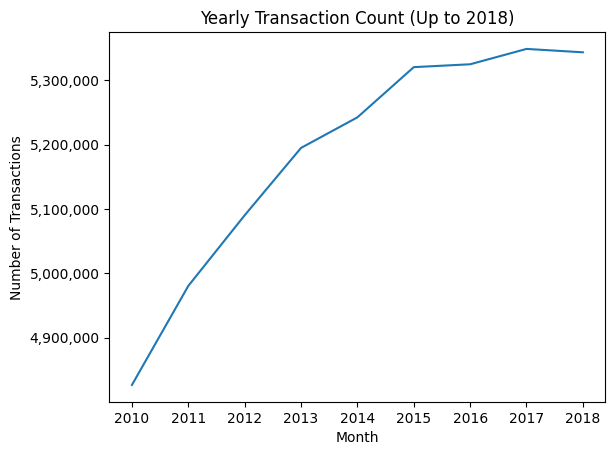

In [45]:
monthly_txn = Unified_Transaction_Dataset[
    Unified_Transaction_Dataset['date'] < '2019-01-01'
].groupby(
    Unified_Transaction_Dataset['date'].dt.to_period('Y')
)['amount'].count()

monthly_txn.index = monthly_txn.index.astype(str)

monthly_txn.plot()

plt.title('Yearly Transaction Count (Up to 2018)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.ticklabel_format(style='plain', axis='y')


plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)

plt.show()

#### Comments 
##### The number of transactions appears to be increasing at the fast rate over years. Therefore one could say the number of transactions follows a exponential distribution i.e they are exponentially increasing

##### What is the total transaction amount per year?


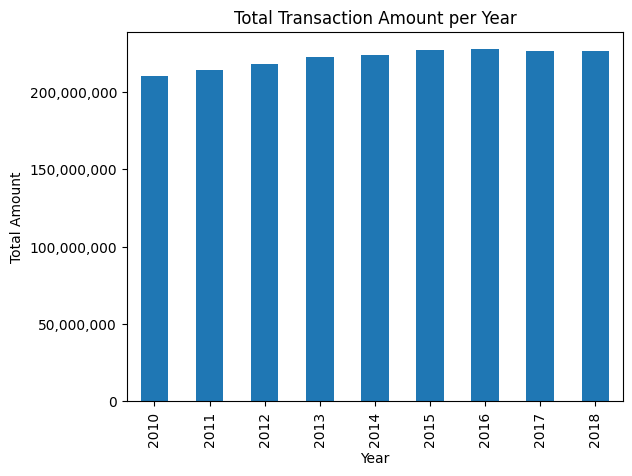

In [46]:
# Group by year and sum amounts
yearly_amount =  Unified_Transaction_Dataset[
    Unified_Transaction_Dataset['date'] < '2019-01-01'
].groupby(
    Unified_Transaction_Dataset['date'].dt.year
)['amount'].sum()

# Plot
yearly_amount.plot(kind='bar')

plt.title('Total Transaction Amount per Year')
plt.xlabel('Year')
plt.ylabel('Total Amount')

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)


plt.show()



##### What Does the Transaction Amounts Look Like?

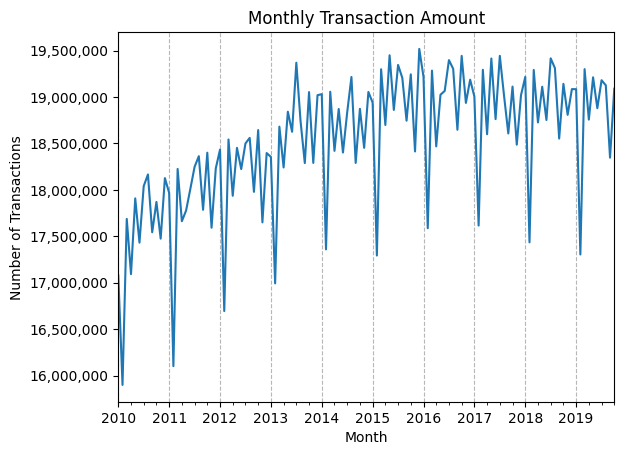

In [54]:
Unified_Transaction_Dataset.groupby(Unified_Transaction_Dataset['date'].dt.to_period('M'))['amount'].sum().plot()

plt.title('Monthly Transaction Amount')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)
plt.grid(axis='x', linestyle='--', alpha=0.9)  
plt.show()

#### Comments

##### The transactions amounts appears to have increased from 2010 to 2014, showing growth both year-on-year and month-on-month
##### After 2014, the transactions amounts appears to have stabilized, suggesting that the customer base may have reached maturity
##### As a result we can see that the transaction amounts are increasing exponentially - follows an exponential distrubution
##### There appears to be a significant drop at the beginning of the year

#### Furthemore 
##### An interesting obeservation is the huge decline at the begginng of the each year and a great analyst investigate that.
##### Lets investigate this decline

#### Claims / Assumptions : 

##### Many people don’t transact much during:
##### Seasonal holidays
##### End-of-year holidays (Dec) → January (Customer Behavior)

#### Data Gaps
##### Check if your dataset starts mid-month or if some early transactions are missing
##### Sometimes January looks low because your dataset is incomplete

#### Settlement Delays
##### Some banks or systems record transactions late



#### What does the transactions look like?

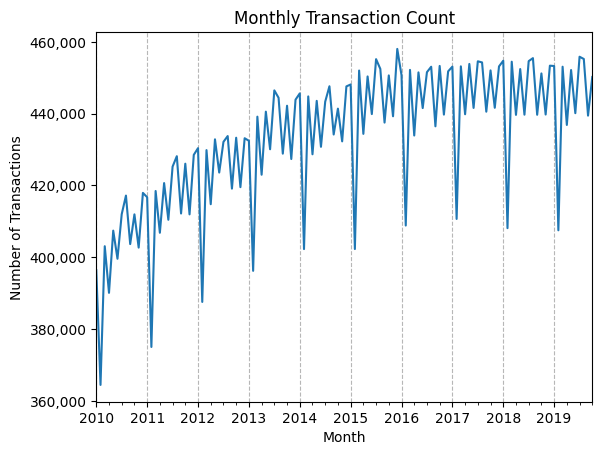

In [56]:
Unified_Transaction_Dataset.groupby(Unified_Transaction_Dataset['date'].dt.to_period('M'))['amount'].count().plot()

plt.title('Monthly Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)
plt.grid(axis='x', linestyle='--', alpha=0.9)  
plt.show()

##### Since the monthly transactions counts and the monthly transactions amount graphs look the same i can therefore conclude that the number of transactions and the transaction amount are hughly correlated i.e the more transaction made the more money you spend

#### Checking for the transactions on a daily level

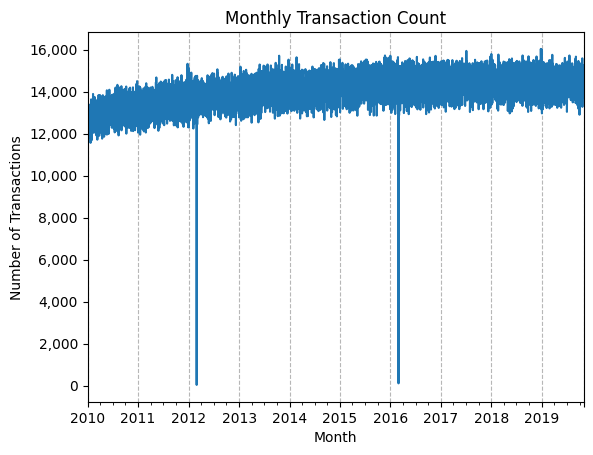

In [58]:
Unified_Transaction_Dataset.groupby(Unified_Transaction_Dataset['date'].dt.to_period('D'))['amount'].count().plot()

plt.title('Monthly Transactions')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)
plt.grid(axis='x', linestyle='--', alpha=0.9)  
plt.show()

##### Therefore looking at this data from a daily view, we see that there's no signicant decline at the beggining each year. Thefore this means December spending and January holidays are does not have a huge effect shown from the graphs above.
##### This means that there's inconsistencies within this data

#### General insights
##### Checking outliers or extreme values

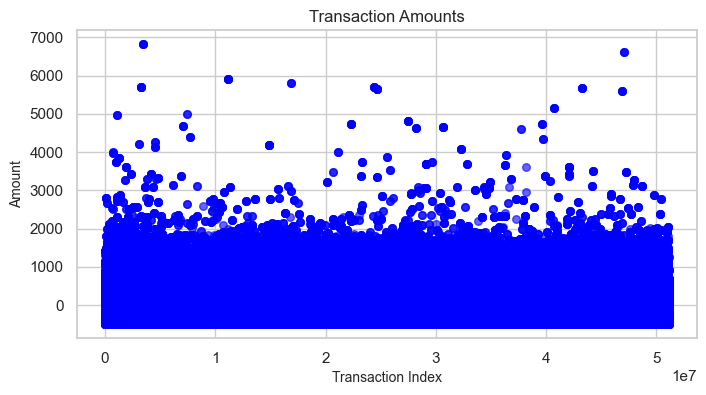

In [93]:
plt.figure(figsize=(8,4))
plt.scatter(
    Unified_Transaction_Dataset.index,
    Unified_Transaction_Dataset['amount'],
    alpha=0.6,           # transparency
    c='blue',         # color
   # edgecolors='black',  # outline of points
    s=30                 # size of points
)

# Titles and labels
plt.title('Transaction Amounts', fontsize=12)
plt.xlabel('Transaction Index', fontsize=10)
plt.ylabel('Amount', fontsize=10)
plt.show()

##### Which card makes most transactions?


In [96]:
Unified_Transaction_Dataset['card_brand'].value_counts()  ### we draw a bar graph with this but i prefer this output


card_brand
Mastercard    26640082
Visa          19343985
Amex           3428736
Discover       1702534
Name: count, dtype: int64

### Comment
##### Most transactions are coming from the mastercard therefore we get more revenue from mastercard

In [59]:
Unified_Transaction_Dataset.groupby('card_brand')['amount'].mean()


card_brand
Amex         42.82
Discover     42.56
Mastercard   42.60
Visa         42.95
Name: amount, dtype: float64

### Comment
##### The 4 types of card brands shows a similar mean. This could mean that customers are not spending more just because of card type.


##### In this table, We observe that many customers want to exceed their limits, they enter incorrect PINs and CVV codes. Therefore Highlighting proper usage is important, as repeated errors can trigger fraud alerts and result in the card being blocked.

In [99]:
Unified_Transaction_Dataset.groupby('use_chip')['errors'].value_counts()

use_chip            errors                                             
Chip Transaction    Insufficient Balance                                   187163
                    Bad PIN                                                 50406
                    Technical Glitch                                        36590
                    Bad Zipcode                                              1616
                    Bad PIN,Insufficient Balance                              419
                    Insufficient Balance,Technical Glitch                     307
                    Bad PIN,Technical Glitch                                  125
                    Bad Zipcode,Insufficient Balance                           10
                    Bad Zipcode,Technical Glitch                                4
Online Transaction  Insufficient Balance                                    46448
                    Bad Card Number                                         29622
                    Bad CV

##### Which age groupn makes the highest number of transactions?

<Axes: >

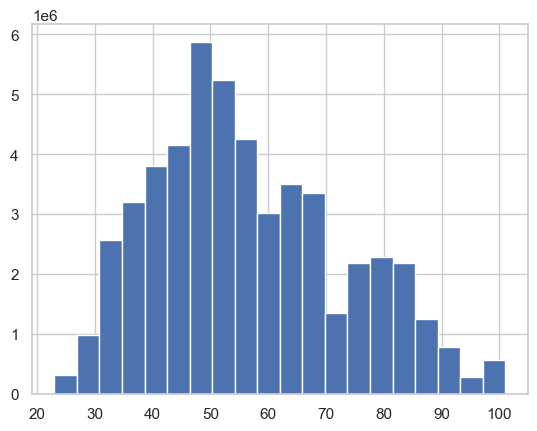

In [102]:
Unified_Transaction_Dataset['current_age'].hist(bins=20)


##### A question to consider : How much is this age transacting?

##### Which gender spent most money on avarage?

In [103]:
Unified_Transaction_Dataset.groupby('gender')['amount'].mean()

gender
Female   42.91
Male     42.58
Name: amount, dtype: float64

##### Females have the highest number of transaction on avarage. Are Female making more money than males? What makes female to have the highest avarage spent?

#### Through Data Intarrogation, we ask relevant question. We also strive to answer relevant questions. We understand our data, our customer,our business and we are able to make more informed and strategic decisions. 

#### This dataset was loaded into Tableau to create a Basic Report, that follows a story telling. Access the report via this link: 

##### https://public.tableau.com/views/DataAnalyticsTableauPortfolio/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

####  Last Phase : Forecasting using Machine Learning - Demand

#### Creating a series for number of transaction 

In [245]:

# Create monthly transaction count
monthly_Txn = Unified_Transaction_Dataset.resample('ME', on='date')['amount'].count()

# Convert to DataFrame
monthly_Txn = monthly_Txn.reset_index()
monthly_Txn.columns = ['date', 'Txn_count']

#### Plotting the number of transaction and checking for the moving avarage

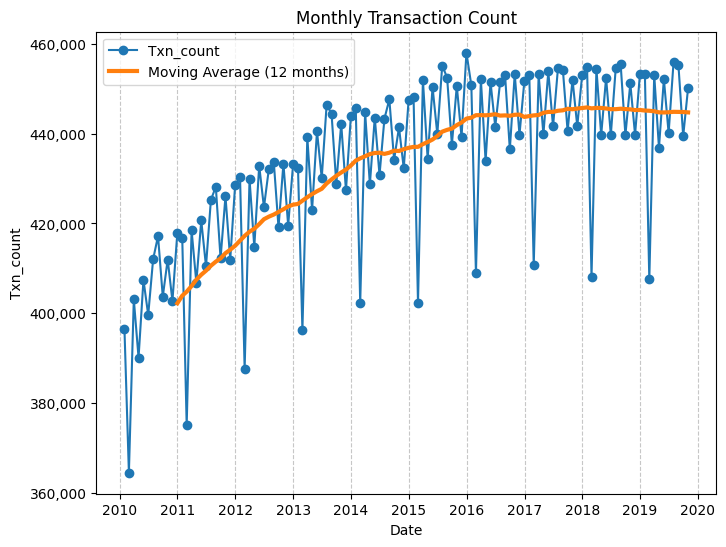

In [246]:
plt.figure(figsize=(8,6))

monthly_Txn['moving_avg'] = monthly_Txn['Txn_count'].rolling(window=12).mean()

plt.plot(monthly_Txn['date'], monthly_Txn['Txn_count'], label='Txn_count', marker='o')

plt.plot(monthly_Txn['date'], monthly_Txn['moving_avg'], 
         label='Moving Average (12 months)', linewidth=3)

plt.title('Monthly Transactions')
plt.xlabel('Date')
plt.ylabel('Txn_count')

plt.legend()

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter('{x:,.0f}')
)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Creating an index for the number of transaction 

In [247]:
# Get the index as a column
monthly_Txn['Date'] = monthly_Txn.index

In [248]:
monthly_Txn

,date,Txn_count,moving_avg,Date
0,2010-01-31,396391,NaN,0
1,2010-02-28,364444,NaN,1
2,2010-03-31,403085,NaN,2
3,2010-04-30,390095,NaN,3
4,2010-05-31,407427,NaN,4
...,...,...,...,...
113,2019-06-30,440146,444774.000000,113
114,2019-07-31,455871,444875.833333,114
115,2019-08-31,455248,444856.250000,115
116,2019-09-30,439462,444836.083333,116


#### Training, fitting and making prediction for the model

In [249]:
# Create Lag_1 column
monthly_Txn['Lag_12'] = monthly_Txn['Txn_count'].shift(12)

# Drop rows where Lag_1 is NaN (first row)
monthly_Txn_model = monthly_Txn.dropna(subset=['Lag_12'])

# Features and target
X = monthly_Txn_model[['Lag_12']]
y = monthly_Txn_model['Txn_count']

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as
# the training data
y_pred = pd.Series(model.predict(X), index=monthly_Txn_model.index) # aligns with your actual dates

#### Actual transactions vs Fitted transactions

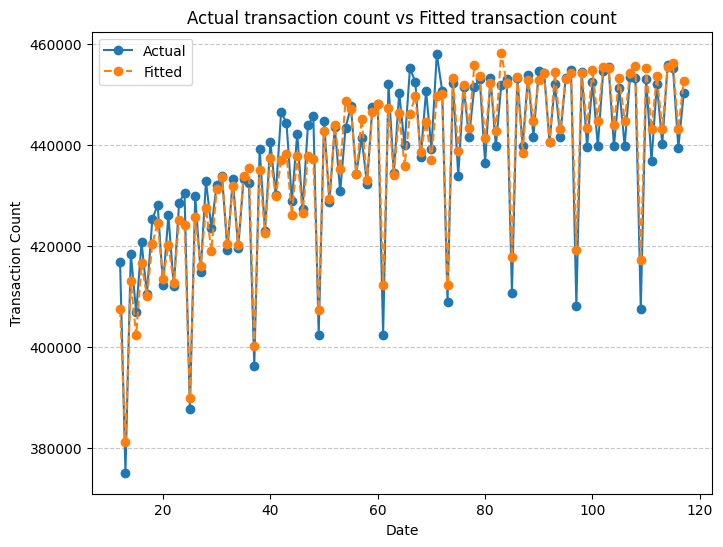

In [294]:

# Plot (optional)
plt.figure(figsize=(8,6))
plt.plot( y, label='Actual', marker='o')
plt.plot( y_pred, label='Fitted', linestyle='--', marker='o')
plt.title('Actual transactions vs Fitted transactions')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Checking for the R-squad to evaluate the model

In [252]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# R-squared score
r2 = r2_score(y, y_pred)

print(f"R-squared: {r2:.3f}")

R-squared: 0.940


##### R² of 0.0.94 means 94% of the variance in your monthly transaction counts is explained by your model (the Lag-12 linear regression).
##### only 6% of the variation is unexplained by your predictor.

106

#### Forecasting

In [285]:
# Length of the forecast
n_forecast = 12

# Last integer index in your DataFrame
last_index = monthly_Txn.index[-2]  # this is an int

# Create forecast index as integers continuing from last_index + 1
forecast_index = range(last_index + 1, last_index + 1 + n_forecast)

# Create forecast series with integer index
y_forecast = pd.Series(forecast_values, index=forecast_index)


#### Actual vs Predicted vs Forecasted transactions

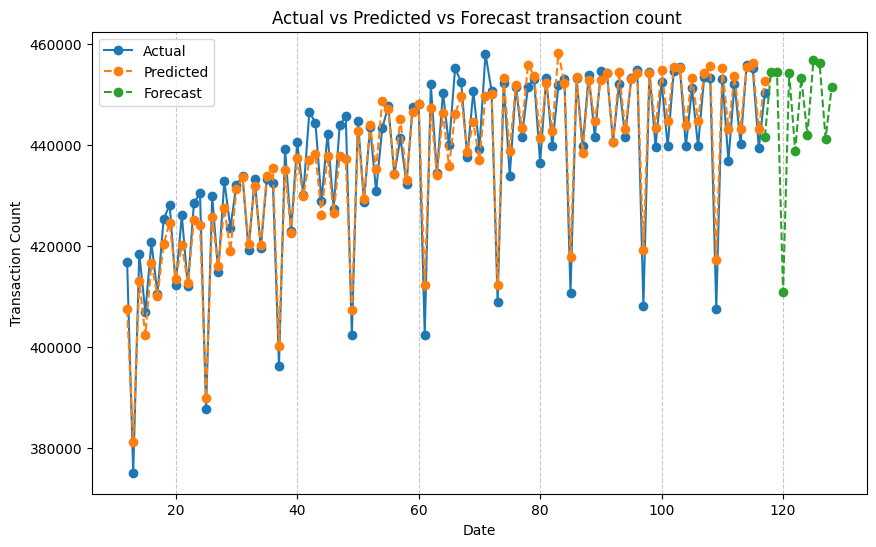

In [298]:
plt.figure(figsize=(10,6))
plt.plot(y, label='Actual', marker='o')
plt.plot( y_pred, label='Predicted', linestyle='--', marker='o')
plt.plot( y_forecast, label='Forecast', linestyle='--', marker='o')
plt.title('Actual vs Predicted vs Forecasted transactions ')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### This what the next 12 months look like. We see that no increase or decrease. Things look contant  - meanining we see no demand. This means we need to implement a strategy that will increase demand. I will not propose a strategy since that is beyond the scope of this portfolio. Thank you

In [ ]:
plt.savefig("images/forecast.png")